<a href="https://colab.research.google.com/github/ankit-rathi/Quantvesting_v3/blob/main/notebooks/04_quantvesting_run.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Quantvesting

## End-to-End Run

The notebook is a thin client of the Quantvesting engine.

In [1]:
!pip install -q ta pyxirr matplotlib


In [2]:
# 1. Environment & imports

from google.colab import drive
drive.mount('/content/drive')

import sys

PROJECT = "/content/drive/My Drive/quantvesting_v3"
MARKET_DATA_DIR = PROJECT + "/market_data"
PORTFOLIO_ID = "ankit"
PORTFOLIO_DATA_DIR = PROJECT + f"/portfolio_data/{PORTFOLIO_ID}"

# Phase A controls
REFRESH_SCREENER = False   # True only when a new Screener XLSX has arrived
EOD_RUN = False            # True only for the final run of the day

sys.path.insert(0, PROJECT + "/src")

from quantvesting import (
    Quantvesting,
    load_config,
    load_market_data,
    load_portfolio_data,
    create_run_id,
    PROSPECT_DISPLAY_COLUMNS,
    PORTFOLIO_DISPLAY_COLUMNS,
)

RUN_ID = create_run_id()


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# 2. Load configuration and optionally refresh shared Screener data

config = load_config(
    PROJECT + "/config/strategy.yaml"
)

qv = Quantvesting(config)

if REFRESH_SCREENER:
    df_screener = qv.ingest_screener(MARKET_DATA_DIR)
    print(f"Screener CSV refreshed: {len(df_screener):,} securities")

market_data = load_market_data(MARKET_DATA_DIR)
portfolio_data = load_portfolio_data(
    PORTFOLIO_DATA_DIR,
    portfolio_id=PORTFOLIO_ID,
)


In [4]:
# 3. Prospect analysis

df_prospects = qv.prospects(
    market_data,
    portfolio_data=portfolio_data,
    include_portfolio=True,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_prospects,
    columns=PROSPECT_DISPLAY_COLUMNS,
    sort_by="CumlRnk",
    ascending=True,
)


,Symbol,FTT,Dev%_200,Dev%_PE,Spread%,Conviction,Cyclical,RSI_14,RSP,FTT%,ATH%,Gained%,CumlRnk,ROE%/PE,Criteria,Strategy,Category,InFolio
0,INFY,1972.00,-14.53,-41.25,15.91,X-LC,NC,47.0,69.79,76.12,69.78,13.64,1.0,2.1,X40,NTT,IT,DM
1,TCS,4230.71,-11.78,-44.31,14.29,X-LC,NC,47.0,65.62,84.94,84.94,16.02,2.0,3.1,X40,ATH,IT,DM
2,TMPV,600.00,-8.74,-84.91,4.52,X-LC,DC,36.0,32.99,86.25,254.64,9.66,3.0,54.0,XY24,NTT,AUTO,DM
3,HINDUNILVR,2922.00,-9.84,-42.16,6.49,X-LC,NC,37.0,22.74,44.94,44.34,0.00,4.0,1.0,XY25,NTT,FMCG,DM
4,BSE,4391.73,3.53,-19.43,14.93,X-LC,NC,36.0,14.58,31.21,31.21,64.48,5.0,1.0,X40N,ATH,MISC,NA
5,HCLTECH,1853.42,-3.36,-13.84,11.32,X-LC,NC,55.0,87.85,40.20,40.20,29.13,6.0,1.2,X40,ATH,IT,DM
6,ITC,452.00,-15.37,-31.57,10.69,X-LC,NC,28.0,24.13,69.54,74.02,0.00,7.0,1.7,X40,NTT,FMCG,DM
7,M&M,3762.88,2.59,-6.96,4.85,X-LC,DC,57.0,85.76,10.35,10.35,17.56,8.0,0.9,X40N,ATH,AUTO,DM
8,RELIANCE,1952.00,-6.47,-7.13,6.67,X-LC,SC,49.0,51.04,49.40,21.30,3.80,9.0,0.4,XY25,BTT,REFINERIES,DM+SV
9,NESTLEIND,1377.00,9.82,-7.22,12.30,X-LC,NC,45.0,62.85,-5.94,5.20,28.32,10.0,1.0,XY25,NTT,FMCG,NA


/content/drive/My Drive/quantvesting_v3/src/quantvesting/portfolio.py:436: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  dates = pd.to_datetime(dates)


,Symbol,Today P/L%,Current P/L%,FTT%,OTT%,FTT Amt,Current P/L,Current,FTT,Dev%_PE,RSI_14,Conviction,Spread%,CumlRnk,RRR Ind,CurrAlloc%,Gained%,Criteria,Strategy,Category
78,UNITDSPR,-0.34,11.34,8.46,20.77,22055.0,26556.0,260700.0,1644.00,-5.11,58.0,X-MC,11.24,64.0,1.20,1.69,25.32,X40N,NTT,BREWERIES
77,TTKPRESTIG,-1.45,-23.83,31.40,0.09,24105.0,-24011.0,76766.0,770.00,-7.35,39.0,M-SC,9.66,250.0,-1.00,0.50,38.17,OX40N,NTT,DURABLES
52,M&M,-0.34,7.68,10.35,18.82,26823.0,18479.0,259160.0,3762.88,-6.96,57.0,X-LC,4.85,25.0,0.69,1.68,17.56,X40N,ATH,AUTO
27,GLAXO,5.30,21.64,11.56,35.69,28021.0,43116.0,242400.0,3380.16,-8.73,86.0,X-MC,9.82,56.0,1.54,1.58,44.07,X40,ATH,PHARMA
67,SIS,0.24,-4.78,27.35,21.26,28915.0,-5309.0,105723.0,528.00,103.25,38.0,H-SC,20.56,168.0,-0.18,0.69,57.19,OX40N,NTT,MISC
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9,BANDHANBNK,-0.53,-18.41,135.85,92.42,308738.0,-51295.0,227264.0,400.00,45.11,37.0,H-SC,12.00,174.0,-0.17,1.48,26.28,XY24,NTT,BANKS
2,ACC,-1.18,-42.34,203.17,74.81,314117.0,-113520.0,154608.0,3906.00,-42.69,34.0,X-SC,11.71,85.0,-0.36,1.00,3.29,XY24,BTT,CEMENT
62,REPCOHOME,3.00,-22.22,144.04,89.82,320995.0,-63654.0,222851.0,880.00,NaN,36.0,H-nan,4.37,161.0,-0.20,1.45,7.13,XY24,NTT,FINANCE
6,AWL,-0.68,-35.00,156.97,67.02,363517.0,-124725.0,231584.0,485.00,-52.14,45.0,X-SC,8.73,81.0,-0.34,1.51,10.12,XY24,NTT,FMCG


## Run date time (IST): 2026-08-19 15:18:36

Deployed:  1.46 C  
Current:  1.58 C  
CAGR/XIRR %: 3.44%

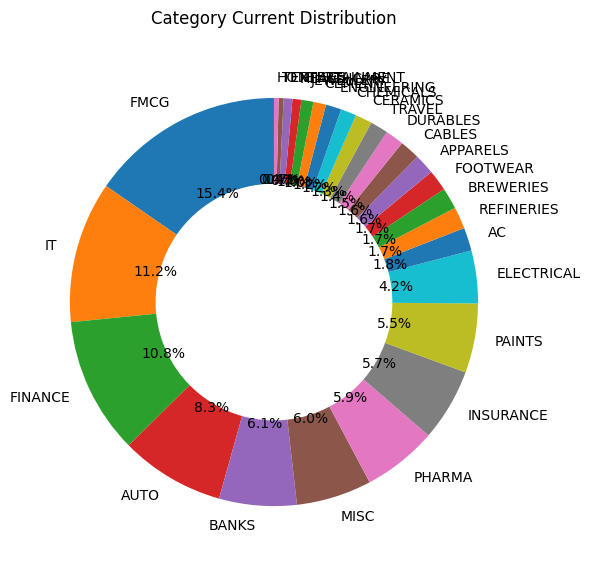

,Current
Category,
FMCG,2365661.0
IT,1723205.0
FINANCE,1664408.0
AUTO,1272967.0
BANKS,944646.0
MISC,918123.0
PHARMA,907638.0
INSURANCE,882183.0
PAINTS,845346.0


In [5]:
# 4. Portfolio analysis

df_portfolio, portfolio_summary = qv.portfolio(
    market_data,
    portfolio_data=portfolio_data,
    eod=EOD_RUN,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
)

qv.display_dataframe(
    df_portfolio,
    columns=PORTFOLIO_DISPLAY_COLUMNS,
    sort_by="FTT Amt",
    ascending=True,
)

qv.display_run_summary(portfolio_summary)

qv.display_portfolio_category_chart(
    df_portfolio,
    category_column="Category",
    value_column="Current",
    title="Category Current Distribution",
)


In [6]:
# 5. Decision layer

df_prospects_actions = qv.prospect_actions(
    df_prospects,
    top_n=10,
)

df_portfolio_actions = qv.portfolio_actions(
    df_portfolio,
)


## End of run

Calculations remain in the engine; notebook cells only orchestrate and present the results. The same structured outputs can later feed an API/Web UI.

In [7]:
# 6. Capital rotation review
# Advisory only: identifies holdings whose thesis is substantially captured
# and compares them with the best currently ranked CORE prospect.
df_rotation = qv.capital_rotation(
    df_prospects,
    df_portfolio,
)

if not df_rotation.empty:
    display(df_rotation)
else:
    print('No capital-rotation candidates at current thresholds.')


No capital-rotation candidates at current thresholds.


## Phase 2 — Premium investment terminal

In [8]:
qv.display_terminal(
    df_portfolio=df_portfolio,
    df_prospects=df_prospects,
    portfolio_summary=portfolio_summary,
    df_rotation=df_rotation,
    df_portfolio_actions=df_portfolio_actions,
    df_prospect_actions=df_prospects_actions,
    portfolio_id=PORTFOLIO_ID,
    run_id=RUN_ID,
    run_datetime=portfolio_summary.get("run_datetime"),
)

qv.display_health_chart(df_portfolio)
qv.display_upside_chart(df_portfolio)
qv.display_prospect_opportunities(df_prospects)